In [1]:
from music21 import stream, note, meter, key, clef
from collections import defaultdict
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random


In [2]:
with open('rhythm_dict/rhythm_dict_with_cleanup_20dec25.pkl', 'rb') as f:
    rhythm_dict = pickle.load(f)

with open('markov_dict/pitch_markov_restrictedG3E6.pkl', 'rb') as f:
    pitch_markov_prob = pickle.load(f)

In [3]:
# ===============================
# GRADE SETTINGS
# ===============================

GRADE_SETTINGS = {

    "initial": {
        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],
        "keys": ["C_major", "D_minor"],
        "position": "5_finger"
    },

    1: {

        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 4, "time_signature": "3/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],

        "keys": [
            "C_major",
            "D_minor",
            "G_major",
            "F_major",
            "A_minor"
        ],
        "position": "any_5_finger"
    }
}

def sample_grade_parameters(grade):

    settings = GRADE_SETTINGS[grade]

    structure = random.choice(settings["structures"])

    difficulty = DIFFICULTY_PROFILES[grade]

    params = {
        "bars": structure["bars"],
        "time_signature": structure["time_signature"],
        "key": random.choice(settings["keys"]),
        "position": settings["position"],
        "max_interval": difficulty["max_interval"],
        "allowed_durations": difficulty["allowed_durations"]
    }

    # Initial grade uses one hand only
    if grade == "initial":
        params["hand"] = random.choice(["RH", "LH"])

    return params

# ===============================
# DIFFICULTY ENGINE
# ===============================

DIFFICULTY_PROFILES = {

    "initial": {

        "max_interval": 4,
        "preferred_interval": 2,

        "range": (55, 76),

        "use_position_range": True,

        "allowed_durations": {1.0, 0.5, 2.0},

        "step_bias": 1.5,
        "leap_penalty": 0.6,

        "accidentals": False,

        "cadence_strength": 3.0
    },

    1: {

        "max_interval": 5,
        "preferred_interval": 3,

        "range": (55, 76),
        "use_position_range": True,

        "allowed_durations": {1.0, 0.5, 2.0, 1.5},

        "step_bias": 1.5,
        "leap_penalty": 0.8,

        "accidentals": True,

        "cadence_strength": 2.5
    },

    2: {

        "max_interval": 7,
        "preferred_interval": 4,

        "range": (53, 83),

        "allowed_durations": {1.0, 0.5, 2.0, 1.5, 0.25},

        "step_bias": 1.3,
        "leap_penalty": 0.9,

        "accidentals": True,

        "cadence_strength": 2.0
    }
}

# ===============================
# FIVE FINGER POSITIONS (ABRSM Initial)
# ===============================

RH_POSITIONS = {
    "C_major": [60, 62, 64, 65, 67],  # C D E F G
    "D_minor": [62, 64, 65, 67, 69]   # D E F G A
}



def build_five_finger_position(tonic_midi, scale_type):

    scale = sorted(build_scale(tonic_midi, scale_type))

    # choose 5 consecutive scale notes
    start = random.randint(0, len(scale) - 5)

    return scale[start:start + 5]

# ===============================
# KEY SETTINGS
# ===============================

SCALE_PATTERNS = { #semitone distances from the tonic
    "major": [0, 2, 4, 5, 7, 9, 11],
    "natural_minor": [0, 2, 3, 5, 7, 8, 10],
    "harmonic_minor": [0, 2, 3, 5, 7, 8, 11]
} 



def build_scale(tonic_midi, scale_type, octaves=3):

    intervals = SCALE_PATTERNS[scale_type]

    notes = set()

    for o in range(-1, octaves):
        for i in intervals:
            notes.add(tonic_midi + i + 12*o)

    return notes

def build_triad(tonic_midi, scale_type): #builds tonic triad
    scale = sorted(build_scale(tonic_midi, scale_type))
    return [scale[0], scale[2], scale[4]]


# def build_cadences(tonic_midi, scale_type, bars):

#     scale = sorted(build_scale(tonic_midi, scale_type))

#     tonic_triad = [scale[0], scale[2], scale[4]]
#     dominant_triad = [scale[4], scale[6], scale[1]]

#     if bars == 4:
#         return {2: dominant_triad, 4: tonic_triad}


def build_key_settings(tonic_midi, scale_type, music21_name):

    notes = build_scale(tonic_midi, scale_type)
    triad = build_triad(tonic_midi, scale_type)

    return {
        "notes": notes,
        "start": triad,
        "music21_key": music21_name,
        "scale_type": scale_type,
        "tonic_midi": tonic_midi
    }


KEY_SETTINGS = {

    "C_major": build_key_settings(60,"major",("C","major")),
    "D_minor": build_key_settings(62,"natural_minor",("D","minor")),

    "G_major": build_key_settings(67,"major",("G","major")),
    "F_major": build_key_settings(65,"major",("F","major")),
    "A_minor": build_key_settings(69,"natural_minor",("A","minor"))
}

def phrase_direction(bar_number, bars):
    if bars == 4:
        if bar_number == 1:
            return "up"

        if bar_number == 2:
            return "peak"

        if bar_number == 3:
            return "down"

        return "cadence"

    if bars == 6:
        if bar_number in [1, 4]:
            return "up"

        if bar_number in [2, 5]:
            return "peak"

        if bar_number == 3:
            return "down"

        return "cadence"

    return "neutral"

# ===============================
# UTILITY FUNCTIONS
# ===============================

def normalize(weight_dict):
    total = sum(weight_dict.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in weight_dict.items()}

def weighted_sample(prob_dict):
    if not prob_dict:
        return None
    items = list(prob_dict.keys())
    weights = list(prob_dict.values())
    return random.choices(items, weights=weights, k=1)[0]

def rest_probability(bars):
    if bars == 4:
        return 0.20   # 20% chance
    if bars == 6:
        return 0.30   # 30% chance
    return 0.20


# ===============================
# GENERATOR HELPER FUNCTIONS
# ===============================


def choose_position(params, settings):

    if params["position"] == "5_finger":
        return RH_POSITIONS[params["key"]]

    if params["position"] == "any_5_finger":
        return build_five_finger_position(
            settings["tonic_midi"],
            settings["scale_type"]
        )
    

def sample_distinct_rhythms(valid_rhythms):

    A = sample_rhythm(valid_rhythms)

    B = A
    while B == A:
        B = sample_rhythm(valid_rhythms)

    C = A
    while C in (A, B):
        C = sample_rhythm(valid_rhythms)

    return A, B, C


def build_rhythm_plan(bars, A, B, C, valid_rhythms): #musical repetition and structure

    if bars == 4:
        return [A, A, B, A]

    if bars == 6:
        return [A, A, B, B, A, C]

    return [sample_rhythm(valid_rhythms) for _ in range(bars)]

# ===============================
# RHYTHM FILTER
# ===============================

def is_valid_rhythm(pattern, beats_per_bar, difficulty):

    if abs(sum(pattern) - beats_per_bar) > 1e-6:
        return False

    allowed = difficulty["allowed_durations"]

    return all(d in allowed for d in pattern)

def get_valid_rhythms(rhythm_dict, time_signature, difficulty):

    beats = int(time_signature.split("/")[0])

    patterns = rhythm_dict.get(time_signature, {})

    return {
        p: c
        for p, c in patterns.items()
        if is_valid_rhythm(p, beats, difficulty)
    }

def sample_rhythm(initial_rhythms):
    probs = normalize(initial_rhythms)
    return weighted_sample(probs)

# ===============================
# MARKOV CONSTRAINTS
# ===============================

def constrained_transitions(prev_note, pitch_markov_prob, allowed_notes, difficulty):

    raw = pitch_markov_prob.get(prev_note, {})
    filtered = {}

    STAFF_LIMITS = (48, 76)  # C3 – E5
    low_limit, high_limit = STAFF_LIMITS

    max_interval = difficulty["max_interval"]
    if difficulty.get("use_position_range"):
        low = min(allowed_notes)
        high = max(allowed_notes)
    else:
        low, high = difficulty["range"]

    for nxt, prob in raw.items():

        if nxt not in allowed_notes:
            continue

        if abs(nxt - prev_note) > max_interval:
            continue

        if nxt < low or nxt > high:
            continue

        if nxt < low_limit or nxt > high_limit:
            continue

        filtered[nxt] = prob

    return filtered

def pedagogical_bias(prev_note, candidates, bar_number, bars, highest_note, difficulty):

    step_bias = difficulty["step_bias"]
    leap_penalty = difficulty["leap_penalty"]
    preferred = difficulty["preferred_interval"]

    for nxt in list(candidates.keys()):

        interval = abs(nxt - prev_note)

        # discourage repeating the same note
        if nxt == prev_note:
            candidates[nxt] *= 0.5

        # encourage stepwise motion
        if interval <= preferred:
            candidates[nxt] *= step_bias

        # discourage big jumps
        elif interval >= preferred + 2:
            candidates[nxt] *= leap_penalty

        # phrase direction
        direction = phrase_direction(bar_number, bars)

        if direction == "up" and nxt > prev_note:
            candidates[nxt] *= 1.4

        if direction == "down" and nxt < prev_note:
            candidates[nxt] *= 1.4

        if direction == "peak" and nxt > prev_note:
            candidates[nxt] *= 1.2

        if direction == "cadence" and nxt < prev_note:
            candidates[nxt] *= 1.5

        # discourage repeating the highest note
        if prev_note == highest_note and nxt >= prev_note:
            candidates[nxt] *= 0.3

    return candidates

# ===============================
# BAR GENERATION
# ===============================

def generate_bar(
    prev_note,
    bar_number,
    bars,
    highest_note,
    rhythm,
    pitch_markov_prob,
    allowed_notes,
    cadences,
    difficulty
):

    bar_notes = []

    for i, dur in enumerate(rhythm):

        highest_note = max(highest_note, prev_note)

        # Get candidate transitions
        candidates = constrained_transitions(
            prev_note,
            pitch_markov_prob,
            allowed_notes,
            difficulty
        )

        # Apply pedagogical musical bias
        candidates = pedagogical_bias(
            prev_note,
            candidates,
            bar_number,
            bars,
            highest_note,
            difficulty
        )
        # Cadence bias on final note of the bar
        is_last_note = (i == len(rhythm) - 1)

        if is_last_note and bar_number in cadences:

            target = cadences[bar_number]

            if isinstance(target, list):
                for t in target:
                    candidates[t] = candidates.get(t, 0) * difficulty["cadence_strength"]
            else:
                candidates[target] = candidates.get(target, 0) * difficulty["cadence_strength"]

        # Normalize probabilities
        candidates = normalize(candidates)

        # Safety fallback
        if not candidates:
            next_note = min(allowed_notes,key=lambda x: abs(x - prev_note))
        else:
            next_note = weighted_sample(candidates)

        bar_notes.append((next_note, dur))

        prev_note = next_note

    return bar_notes, prev_note, highest_note

# ===============================
# FULL EXERCISE GENERATOR
# ===============================

def generate_exercise(pitch_markov_prob, rhythm_dict, grade="initial"):

    params = sample_grade_parameters(grade)

    bars = params["bars"]
    time_signature = params["time_signature"]
    key_name = params["key"]

    difficulty = DIFFICULTY_PROFILES[grade]
    settings = KEY_SETTINGS[key_name]

    tonic_midi = settings["tonic_midi"]
    scale_type = settings["scale_type"]

    # Hand selection
    if grade in ["initial", 1]:
        hands = [random.choice(["RH", "LH"])]
    else:
        hands = ["RH", "LH"]

    # Valid rhythms
    valid_rhythms = get_valid_rhythms(
        rhythm_dict,
        time_signature,
        difficulty
    )

    if not valid_rhythms:
        raise ValueError("No valid rhythms for this grade/time signature")

    # Motifs
    motif_A, motif_B, motif_C = sample_distinct_rhythms(valid_rhythms)

    rhythm_plan = build_rhythm_plan(
        bars,
        motif_A,
        motif_B,
        motif_C,
        valid_rhythms
    )

    # Optional rest
    include_rest = (
        grade == "initial"
        and random.random() < rest_probability(bars)
    )

    rest_bar = None
    if include_rest and bars > 2:
        rest_bar = random.randint(2, bars - 1)

    exercise = {}

    for hand in hands:

        # Position
        position_notes = choose_position(params, settings)
        allowed_notes = set(position_notes)

        start_notes = [position_notes[0], position_notes[2], position_notes[4]]
        cadences = {bars: position_notes[0]}

        prev_note = random.choices(
            start_notes,
            weights=[3, 1, 1]
        )[0]

        hand_bars = []

        highest_note = prev_note

        for bar_number in range(1, bars + 1):

            # Rest bar
            if bar_number == rest_bar:
                beats = int(time_signature.split("/")[0])
                hand_bars.append([("rest", beats)])
                prev_note = random.choice(start_notes)
                continue

            rhythm = motif_A if bar_number == bars else rhythm_plan[bar_number - 1]

            bar, prev_note, highest_note = generate_bar(
                prev_note,
                bar_number,
                bars,
                highest_note,
                rhythm,
                pitch_markov_prob,
                allowed_notes,
                cadences,
                difficulty
            )

            hand_bars.append(bar)

        # LH transpose
        if hand == "LH":
            hand_bars = [
                [
                    (p - 12, d) if p != "rest" else ("rest", d)
                    for p, d in bar
                ]
                for bar in hand_bars
            ]

        exercise[hand] = hand_bars

    return exercise, params

# ===============================
# RENDER WITH MUSIC21
# ===============================

def render_exercise(exercise, params):

    key_name = params["key"]
    time_signature = params["time_signature"]

    settings = KEY_SETTINGS[key_name]
    tonic, mode = settings["music21_key"]

    score = stream.Score()
   

    for hand, bars in exercise.items():

        part = stream.Part()

        if hand == "RH":
            part.append(clef.TrebleClef())
        else:
            part.append(clef.BassClef())

        part.append(key.Key(tonic, mode))
        part.append(meter.TimeSignature(time_signature))

        for bar_data in bars:
            m = stream.Measure()

            for pitch, dur in bar_data:
                if pitch == "rest":
                    n = note.Rest()
                else:
                    n = note.Note()
                    n.pitch.midi = pitch

                n.quarterLength = dur
                m.append(n)

            part.append(m)

        score.append(part)

    score.show()


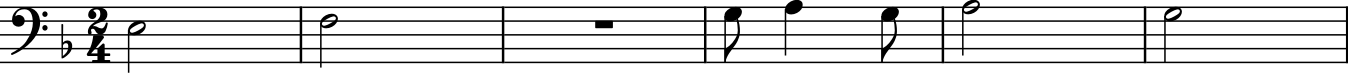

In [4]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade="initial"
)

render_exercise(exercise, params)

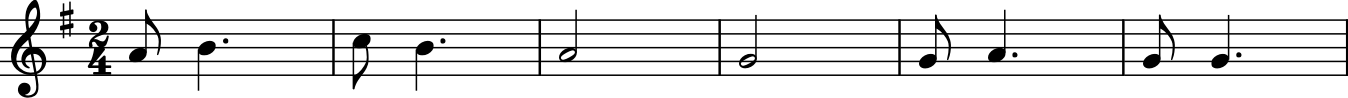

In [118]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade=1
)

render_exercise(exercise, params)